# Stage 3 — Error Analysis

**Цель:** выбрать `CONFIDENCE_THRESHOLD` и решить, нужен ли поиск в агенте.

**Вход:** `predictions/bert_val_preds.parquet`, `predictions/bert_ood_preds.parquet`, `reports/stage1_baseline/metrics.json`

**Выход:**
- `reports/stage3_error_analysis/comparison.json`
- `reports/stage3_error_analysis/fig_accuracy_coverage.png`
- `reports/stage3_error_analysis/bert_errors_sample.csv`
- `predictions/val_merged_preds.parquet` (BERT val + max proba, для Stage 4)

## 3.0 Загрузка предсказаний

In [39]:
import sys
from pathlib import Path
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv(ENV_PATH)

client = OpenAI(
    api_key=os.getenv("VSEGPT_API_KEY"),
    base_url=VSEGPT_BASE_URL,
)


import pandas as pd

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from utils.config import (
    BERT_CALIBRATION_PATH, RANDOM_STATE,
    COL_BERT_PROBA1, COL_BERT_PRED, COL_BERT_CORRECT, TARGET, COL_ID,
    COL_QUERY, COL_NAME, COL_RUBRIC, COL_ADDRESS, COL_REVIEWS, COL_PRICELIST,
    CONFIDENCE_THRESHOLD_DEFAULT, STAGE3_BERT_ERRORS_SAMPLE_PATH,
)
from utils.calibration import load_calibration
from utils.stage3_error_analysis import load_bert_val_predictions, min_sample_size_for_taxonomy

bert_val = load_bert_val_predictions()

calib = load_calibration(BERT_CALIBRATION_PATH)
T = calib['temperature']
print(f'Temperature T = {T:.4f}')
print(f'ECE before={calib.get("ece_before", "n/a")}  '
      f'after={calib.get("ece_after", "n/a")}')

print(f'Медиана {COL_BERT_PROBA1}: {bert_val[COL_BERT_PROBA1].median():.3f}')
print(f'  (ожидаем 0.4–0.7; смещение к 0/1 — сигнал что T не применён)')

Temperature T = 1.1091
ECE before=0.056391  after=0.038949
Медиана bert_proba1: 0.558
  (ожидаем 0.4–0.7; смещение к 0/1 — сигнал что T не применён)


Для повышения качества вероятностных оценок модели была применена temperature scaling на валидационной выборке. Оптимальная температура составила T=1.109, что указывает на небольшую переуверенность исходной модели. После калибровки показатель Expected Calibration Error снизился с 0.056 до 0.039 (≈31%), что свидетельствует об улучшении согласованности между предсказанными вероятностями и фактической точностью. Распределение вероятностей осталось сбалансированным (медиана положительного класса 0.558), что подтверждает корректное применение калибровки.

## 3.1 Ручной анализ ошибок — taxonomy

In [9]:
errors = bert_val[~bert_val[COL_BERT_CORRECT]].copy()

print(f'Ошибок: {len(errors)} ({len(errors)/len(bert_val)*100:.1f}%)')
print(errors[TARGET].value_counts())
print(errors[COL_BERT_PROBA1].describe().round(3))
print(f'FP: {(errors[COL_BERT_PRED] == 1).sum()}  FN: {(errors[COL_BERT_PRED] == 0).sum()}')

Ошибок: 1053 (23.1%)
label
0    545
1    508
Name: count, dtype: int64
count    1053.000
mean        0.506
std         0.268
min         0.015
25%         0.271
50%         0.518
75%         0.740
max         0.958
Name: bert_proba1, dtype: float64
FP: 545  FN: 508


#### Делаем выборку для ручной разметки

На val ошибок BERT много — **1053**; taxonomy нужна, чтобы оценить доли типов и решить,
нужен ли Tavily (`searchable_share` vs 30%).

Целевой объём ручной разметки вычисляется по формуле Кохрана (`min_sample_size_for_taxonomy()`):

$$n = \frac{z^2 \cdot p(1-p)}{\text{margin}^2}$$

- $z \approx 1.96$ (95% CI)  
- $p = 0.30$ (граница «поиск / без поиска»)  
- margin $= \pm10\text{ pp}$ → $n \approx 96$

То есть мы оцениваем пропорции категорий с заданной точностью, а **не** переразмечаем весь val.

**Почему приоритет `high-conf`?**  
Ошибки с `bert_max_proba >= 0.75` — модель уверена, но ошиблась; для taxonomy они
информативнее случайных `low-conf` (где модель и так «сомневается»).  
Отбор до 96 идёт стратифицированно по `TARGET`: сначала `high-conf` по классу, затем добор из остальных.

> `CONFIDENCE_THRESHOLD_DEFAULT` (0.75) используется **только для отбора sample**.  
> Финальный порог routing выбирается отдельно — из кривой §3.2.

In [32]:
n_to_label  = min_sample_size_for_taxonomy()  # 96 — статистически обоснованный минимум
n_per_class = n_to_label // 2

errors = bert_val[~bert_val[COL_BERT_CORRECT]].copy()

# Приоритет 1: high-confidence ошибки — модель уверена, но неправа
# Это самые информативные случаи для taxonomy
high_conf_errors = errors[errors[COL_BERT_MAX_PROBA] >= CONFIDENCE_THRESHOLD_DEFAULT]

# Приоритет 2: добираем до n_to_label стратифицированно по TARGET
parts = []
for label_val in errors[TARGET].unique():
    # Сначала берём high-conf по этому классу
    hc = high_conf_errors[high_conf_errors[TARGET] == label_val]
    rest = errors[
        (errors[TARGET] == label_val) &
        (~errors.index.isin(hc.index))
    ]
    needed = n_per_class
    hc_sample   = hc.sample(min(needed, len(hc)), random_state=RANDOM_STATE)
    rest_sample = rest.sample(
        min(needed - len(hc_sample), len(rest)), random_state=RANDOM_STATE
    )
    parts.append(pd.concat([hc_sample, rest_sample]))

taxonomy_sample = (
    pd.concat(parts)
    .drop_duplicates()
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print(f'Нужно разметить: {n_to_label} (формула Кохрана, ±10pp, 95% CI)')
print(f'Итого в выборке: {len(taxonomy_sample)}')
print(f'High-conf: {(taxonomy_sample[COL_BERT_MAX_PROBA] >= CONFIDENCE_THRESHOLD_DEFAULT).sum()}')
print(taxonomy_sample[TARGET].value_counts())

Нужно разметить: 97 (формула Кохрана, ±10pp, 95% CI)
Итого в выборке: 96
High-conf: 96
label
0    48
1    48
Name: count, dtype: int64


In [51]:
from IPython.display import display, clear_output, HTML
import ipywidgets as widgets
from pathlib import Path
import pandas as pd

from utils.config import (
    COL_QUERY, COL_NAME, COL_ADDRESS, COL_RUBRIC, COL_REVIEWS, COL_PRICELIST,
    COL_BERT_PRED, COL_BERT_PROBA1, COL_BERT_MAX_PROBA,
    TARGET, RANDOM_STATE, STAGE3_BERT_ERRORS_SAMPLE_PATH,
)
from utils.stage3_error_analysis import min_sample_size_for_taxonomy

ERROR_TAXONOMY_KEYS = (
    'fact_verification',
    'hard_semantic',
    'requires_search',
    'label_noise',
    'non_navigational',
    'other'
)

CAT_COLORS = {
    'fact_verification': ('#FAECE7', '#712B13'),
    'hard_semantic':     ('#E1F5EE', '#085041'),
    'requires_search':   ('#E6F1FB', '#0C447C'),
    'label_noise':       ('#FAEEDA', '#633806'),
    'non_navigational':  ('#EEEDFE', '#3C3489'),
    'other':             ('#F1EFE8', '#444441')
}

FIELDS = [
    (COL_QUERY,     'запрос'),
    (COL_NAME,      'название'),
    (COL_ADDRESS,   'адрес'),
    (COL_RUBRIC,    'рубрика'),
    (COL_REVIEWS,   'отзывы'),
    (COL_PRICELIST, 'прайслист')
]

counts      = {k: 0 for k in ERROR_TAXONOMY_KEYS}
labeled_rows = []
state        = {'i': 0}

out = widgets.Output()

BTN_STYLES = {
    'fact_verification': 'info',
    'hard_semantic':     'warning',
    'requires_search':   'success',
    'label_noise':       'danger',
    'non_navigational':  'primary',
    'other':             ''
}
buttons = {
    k: widgets.Button(description=k, button_style=BTN_STYLES[k])
    for k in ERROR_TAXONOMY_KEYS
}
btn_box = widgets.HBox(list(buttons.values()))

def render_example(i):
    if i >= len(taxonomy_sample):
        labeled_df = pd.DataFrame(labeled_rows)
        Path(STAGE3_BERT_ERRORS_SAMPLE_PATH).parent.mkdir(parents=True, exist_ok=True)
        labeled_df.to_csv(STAGE3_BERT_ERRORS_SAMPLE_PATH, index=False)

        summary_html = '<div style="font-family:sans-serif;font-size:13px">'
        summary_html += '<div style="font-weight:500;margin-bottom:8px">Готово! Итоговые счётчики:</div>'
        for cat, cnt in counts.items():
            bg, fg = CAT_COLORS[cat]
            summary_html += (
                f'<span style="background:{bg};color:{fg};padding:2px 10px;'
                f'border-radius:6px;margin:3px;display:inline-block">'
                f'{cat}: {cnt}</span>'
            )
        summary_html += f'<div style="margin-top:8px;color:#888">Сохранено → {STAGE3_BERT_ERRORS_SAMPLE_PATH}</div>'
        summary_html += '</div>'
        with out:
            clear_output(wait=True)
            display(HTML(summary_html))
        return

    row = taxonomy_sample.iloc[i]

    label_color = '#27500A' if row[TARGET] == 1 else '#A32D2D'
    pred_color  = '#27500A' if row[COL_BERT_PRED] == 1 else '#A32D2D'
    label_bg    = '#EAF3DE' if row[TARGET] == 1 else '#FCEBEB'
    pred_bg     = '#EAF3DE' if row[COL_BERT_PRED] == 1 else '#FCEBEB'

    fields_html = ''
    for col, label in FIELDS:
        val = row.get(col, '')
        val = '' if pd.isna(val) else str(val)
        if not val:
            continue
        fields_html += (
            f'<div style="margin-bottom:6px">'
            f'<span style="color:#aaa;font-size:11px;text-transform:uppercase;'
            f'letter-spacing:0.04em">{label}</span><br>'
            f'<span style="font-weight:{"500" if col == COL_QUERY else "400"}">{val}</span>'
            f'</div>'
        )

    counts_html = ' '.join(
        f'<span style="background:{CAT_COLORS[k][0]};color:{CAT_COLORS[k][1]};'
        f'padding:1px 7px;border-radius:5px;font-size:11px">{k}: {v}</span>'
        for k, v in counts.items()
    )

    html = f'''
    <div style="font-family:sans-serif;font-size:13px">
      <div style="color:#888;font-size:12px;margin-bottom:8px">
        Пример {i + 1} / {len(taxonomy_sample)}
      </div>
      <div style="border:0.5px solid #e0e0e0;border-radius:10px;
                  padding:12px 16px;margin-bottom:10px">
        <div style="display:flex;gap:8px;margin-bottom:10px;
                    align-items:center;flex-wrap:wrap">
          <span style="background:{label_bg};color:{label_color};
                       padding:2px 8px;border-radius:6px;font-size:12px">
            label={row[TARGET]}
          </span>
          <span style="background:{pred_bg};color:{pred_color};
                       padding:2px 8px;border-radius:6px;font-size:12px">
            pred={row[COL_BERT_PRED]}
          </span>
          <span style="color:#888;font-size:12px">
            p={row[COL_BERT_PROBA1]:.2f}
          </span>
          <span style="color:#bbb;font-size:12px">
            idx={row.name}
          </span>
        </div>
        {fields_html}
      </div>
      <div style="margin-top:4px">{counts_html}</div>
    </div>'''

    with out:
        clear_output(wait=True)
        display(HTML(html))

def on_click(label):
    def handler(b):
        i   = state['i']
        row = taxonomy_sample.iloc[i]
        counts[label] += 1
        labeled_rows.append({
            'sample_idx':    i,
            'original_idx':  row.name,
            COL_QUERY:       row[COL_QUERY],
            COL_NAME:        row[COL_NAME],
            TARGET:          row[TARGET],
            COL_BERT_PRED:   row[COL_BERT_PRED],
            COL_BERT_PROBA1: row[COL_BERT_PROBA1],
            'category':      label
        })
        state['i'] += 1
        render_example(state['i'])
    return handler

for k, btn in buttons.items():
    btn.on_click(on_click(k))

display(btn_box, out)
render_example(0)

Output()

In [52]:
# Заполни после просмотра примеров:
error_taxonomy = {
    'requires_search':   23,
    'hard_semantic':     17,
    'fact_verification': 15,
    'label_noise':       32,
    'non_navigational':  6,
    'other':             3,
}

searchable_share = (
    error_taxonomy['requires_search']
    / (sum(error_taxonomy.values()) - error_taxonomy['label_noise'])
    if sum(error_taxonomy.values()) > error_taxonomy['label_noise'] else 0.0
)
print(f'Доля ошибок где поиск поможет: {searchable_share:.1%}')

if searchable_share > 0.3:
    print('→ Архитектура агента: cross-encoder → LLM + Tavily search')
else:
    print('→ Архитектура агента: cross-encoder → LLM (без поиска)')

Доля ошибок где поиск поможет: 35.9%
→ Архитектура агента: cross-encoder → LLM + Tavily search


## 3.2 Confidence threshold

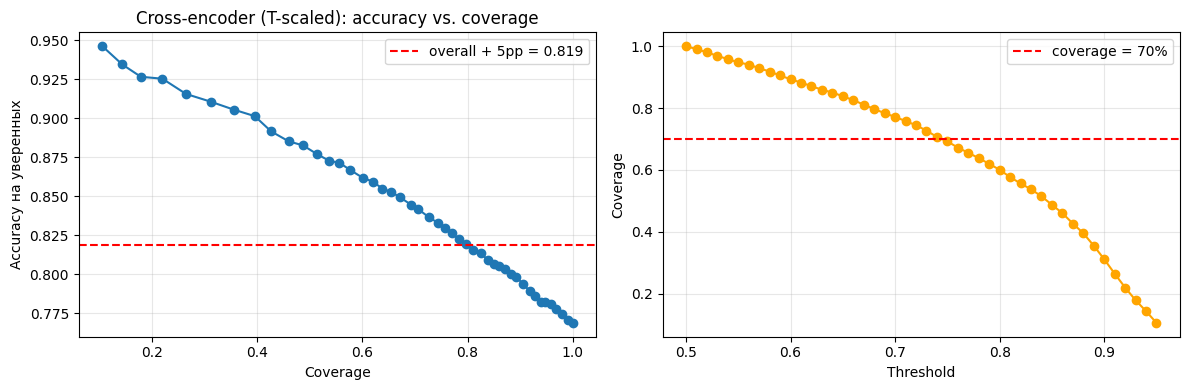

Выбран порог: 0.68
Low-confidence:  925 (20.3%)
Accuracy low:    0.571
Accuracy high:   0.819


In [53]:
import numpy as np
import matplotlib.pyplot as plt
from utils.config import STAGE3_ACCURACY_COVERAGE_FIG_PATH, COL_BERT_MAX_PROBA
from utils.stage3_error_analysis import (
    accuracy_coverage_data, suggest_confidence_threshold, max_confidence,
)

if COL_BERT_MAX_PROBA not in bert_val.columns:
    bert_val[COL_BERT_MAX_PROBA] = bert_val[COL_BERT_PROBA1].map(max_confidence)

overall_acc = bert_val[COL_BERT_CORRECT].mean()
thr_list, accs, coverages = accuracy_coverage_data(bert_val)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(coverages, accs, marker='o')
ax1.axhline(overall_acc + 0.05, color='red', linestyle='--',
            label=f'overall + 5pp = {overall_acc + 0.05:.3f}')
ax1.set_xlabel('Coverage'); ax1.set_ylabel('Accuracy на уверенных')
ax1.set_title('Cross-encoder (T-scaled): accuracy vs. coverage')
ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(thr_list, coverages, marker='o', color='orange')
ax2.axhline(0.70, color='red', linestyle='--', label='coverage = 70%')
ax2.set_xlabel('Threshold'); ax2.set_ylabel('Coverage')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
fig_path = Path(STAGE3_ACCURACY_COVERAGE_FIG_PATH)
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, bbox_inches='tight')
plt.show()

CONFIDENCE_THRESHOLD = suggest_confidence_threshold(bert_val)
print(f'Выбран порог: {CONFIDENCE_THRESHOLD:.2f}')

low_conf  = bert_val[bert_val[COL_BERT_MAX_PROBA] <  CONFIDENCE_THRESHOLD]
high_conf = bert_val[bert_val[COL_BERT_MAX_PROBA] >= CONFIDENCE_THRESHOLD]
print(f'Low-confidence:  {len(low_conf)} ({len(low_conf)/len(bert_val)*100:.1f}%)')
print(f'Accuracy low:    {(low_conf[COL_BERT_PRED]  == low_conf[TARGET]).mean():.3f}')
print(f'Accuracy high:   {(high_conf[COL_BERT_PRED] == high_conf[TARGET]).mean():.3f}')

## 3.3 OOD-анализ

In [54]:
from utils.config import BERT_OOD_PREDS_PATH

bert_ood = pd.read_parquet(BERT_OOD_PREDS_PATH)
print('Cross-encoder на OOD:')
print(bert_ood[COL_BERT_PRED].value_counts(normalize=True).round(3))
print(f'Медиана {COL_BERT_PROBA1} на OOD: {bert_ood[COL_BERT_PROBA1].median():.3f}')

Cross-encoder на OOD:
bert_pred
1    0.533
0    0.467
Name: proportion, dtype: float64
Медиана bert_proba1 на OOD: 0.543


## 3.4 Сохранение отчёта

In [55]:
from utils.stage3_error_analysis import run_stage3

# Передай заполненную taxonomy и порог, если уже выбрал вручную:
summary = run_stage3(
    confidence_threshold=CONFIDENCE_THRESHOLD,
    error_taxonomy=error_taxonomy,
)
summary

2026-06-02 18:05:50,156 - utils.stage3_error_analysis - INFO - Saved D:\My_courses\NLP_ODS_2026\yandex_relevance\reports\stage3_error_analysis\fig_accuracy_coverage.png
2026-06-02 18:05:50,172 - utils.stage3_error_analysis - INFO - Saved D:\My_courses\NLP_ODS_2026\yandex_relevance\reports\stage3_error_analysis\bert_errors_sample.csv (96 rows)
2026-06-02 18:05:50,749 - utils.stage3_error_analysis - INFO - Saved D:\My_courses\NLP_ODS_2026\yandex_relevance\predictions\val_merged_preds.parquet (BERT val for Stage 4 routing)
2026-06-02 18:05:50,760 - utils.stage3_error_analysis - INFO - Stage 3 complete — threshold=0.68, agent=BERT -> LLM + Tavily search, bert_errors=1053


{'confidence_threshold': 0.68,
 'suggested_threshold': 0.68,
 'searchable_share': 0.397,
 'agent_architecture': 'BERT -> LLM + Tavily search',
 'bert_errors_n': 1053,
 'val_preds_path': 'D:\\My_courses\\NLP_ODS_2026\\yandex_relevance\\predictions\\val_merged_preds.parquet',
 'comparison_path': 'D:\\My_courses\\NLP_ODS_2026\\yandex_relevance\\reports\\stage3_error_analysis\\comparison.json',
 'fig_path': 'D:\\My_courses\\NLP_ODS_2026\\yandex_relevance\\reports\\stage3_error_analysis\\fig_accuracy_coverage.png',
 'bert_errors_sample_path': 'D:\\My_courses\\NLP_ODS_2026\\yandex_relevance\\reports\\stage3_error_analysis\\bert_errors_sample.csv',
 'stage1_reference_val_accuracy': 0.6367,
 'bert_val_accuracy': 0.769,
 'temperature': 1.1091078519821167}